# grid_to_df
notebook for converting garstec out hdf5 files to neural network friendly dataframes saved back to hdf5

In [1]:
#misc
import pandas as pd
import numpy as np
import h5py
import os

## import garstec h5 file

In [2]:
garstec_h5 = h5py.File("../grids/Garstec_AS09_chiara.hdf5", 'r') ### EDIT WITH YOUR FILEPATH

print(list(garstec_h5['grid/tracks/track00001']))

['BP_GAIA', 'FeH', 'FeHini', 'G_GAIA', 'LPhot', 'MMaxNucE', 'Mbcz', 'Mcore', 'McoreX', 'MeH', 'MeHini', 'PS', 'RMaxNucE', 'RP_GAIA', 'Rbcz', 'Rcore', 'RcoreX', 'TAMS', 'Teff', 'ZAMSLPhot', 'ZAMSTeff', 'age', 'alphaFe', 'alphaMLT', 'd02fit', 'd02mean', 'dage', 'dif', 'dnuAsf', 'dnuSer', 'dnufit', 'dnufitMos12', 'dnuscal', 'epsfit', 'epsfitMos12', 'errflagSer', 'eta', 'fdnuAsf', 'fdnuSer', 'gcut', 'logg', 'massfin', 'massini', 'modnum', 'name', 'numax', 'numaxAsf', 'nummodSer', 'osc', 'osckey', 'ove', 'radPhot', 'radTot', 'rho', 'rhocen', 'tau0', 'taubcz', 'tauhe', 'volume_weight', 'xcen', 'xini', 'xsur', 'ycen', 'yini', 'ysur', 'zcen', 'zini', 'zsur']


## def and run track_df_gen func

In [3]:
def track_df_no_modes(
    grid: h5py.File,
    track_ids: list[str, ...],
    headers: list[str, str, str] = ["age", "Teff", "LPhot"],
):
    i = 0
    for track_id in track_ids:
        track = grid["grid/tracks/track" + track_id]

        track_array = np.full(len(track[headers[0]]), int(track_id))

        for header in headers:
            track_array = np.column_stack((track_array, np.array(track[header])))

        if i == 0:
            tracks_array = track_array
            i = 1
        else:
            tracks_array = np.vstack((tracks_array, track_array))

    return pd.DataFrame(tracks_array, columns=["track_id"] + headers)

def track_df_gen(grid, track_ids, n_min=15, n_max=25, headers=['age', 'Teff', 'LPhot']):
    """
    Convert garstec hdf5 file (grid) to NN friendly dataframe file for training.
    
    args:
    grid -- garstec hdf5 out file
    track_ids -- list of track ids (including leading zeros) to iterate over

    kwargs:
    n_min -- lower limit of radial order to load/pad
    n_max -- upper limit of radial order to load/pad
    headers -- relevant headers to include in final dataframe (inputs and outputs for training, typically)

    returns:
    pandas dataframe with columns:
        - ['track_id'] -- integer track id from GARSTEC hdf5 out file, no leading 0s
        - [headers] -- columns for each header defined by 'headers' kwarg
        - [nu_headers] -- columns for mode frequency values for radial orders in range n_min->n_max
    
    notes:
    - Operates track by track, and fills missing mode freqencies by padding using GARSTEC dnufit.
    - Modes loaded/filled between a min and max radial order. This must be consistent between all dataframe rows.
    - Warning is printed when padding is occuring. This is unexpected behaviour if radial orders between n_min and n_max should be present for all points in the grid.
    """
    nu_headers = [f"nu_0_{n}" for n in range(n_min, n_max+1)]
    first_switch=0
    for track_id in track_ids:
        print(str(track_id), end="\r")
        track = grid['grid/tracks/track'+track_id]
        
        track_array = np.full(len(track[headers[0]]), int(track_id))

        for header in headers:
            track_array = np.column_stack((track_array, np.array(track[header])))
        
        age = track['age']
    
        points = np.array(age) #np.array(age)[np.where(np.array(age)<=max_age)[0]]
        first_point = points[0]
        last_point = points[-1]
        
        osckeys = track['osckey']
        dnufits = track['dnufit']

        i = 0
        padding_switch = 0
        for point in points:
            n_vals = osckeys[i][1][np.where(osckeys[i][0] == 0)[0]]
            n_upper = n_vals[-1]
            n_lower = n_vals[0]
            dnufit = dnufits[i]
            
            nu_vals = list(track['osc'][i][0][np.where(osckeys[i][0] == 0)])
            if n_upper < n_max:
                nu_max = nu_vals[-1]
                n_diff = n_max - n_upper
                try:
                    nu_upper_pad = (np.linspace(1,n_diff,n_diff)*dnufit)+nu_max
                except:
                    nu_upper_pad = np.full(n_diff, nu_max)
                nu_vals = nu_vals + nu_upper_pad.tolist()
                n_upper=n_max
                padding_switch = 1

            
            if n_lower > n_min:
                nu_min = nu_vals[0]
                n_diff = n_lower - n_min
                try:
                    nu_lower_pad = nu_min - (np.linspace(n_diff,1,n_diff)*dnufit)
                except:
                    nu_lower_pad = np.full(n_diff, nu_min)
                nu_vals = nu_lower_pad.tolist() + nu_vals
                n_lower = n_min
                padding_switch = 1
            
            nu_vals = nu_vals[n_min - n_lower:(n_max - n_lower)+1]
            
            if i == 0:
                nu_vals_arr = nu_vals
            else:
                nu_vals_arr = np.vstack((nu_vals_arr, nu_vals))
            i+=1
        track_array = np.concatenate((track_array, nu_vals_arr), axis=1)
       
        if first_switch == 0:
            tracks_array = track_array
            first_switch = 1
        else:
            tracks_array = np.vstack((tracks_array, track_array))

        if padding_switch == 1:
            print(f"padding! requested radial order range {n_min}->{n_max} exceeded range present in track{track_id}")


    return pd.DataFrame(tracks_array, columns = ['track_id']+headers+nu_headers)

headers = ['massini', 'zini', 'yini', 'alphaMLT', 'alphaFe', 'eta', 'age', 'TAMS', 'logg', 'LPhot', 'Teff', 'FeH', 'numax', 'dnufit', 'numaxAsf', 'xini']

track_ids = [track_name.replace('track', '') for track_name in list(garstec_h5['grid/tracks'])]

garstec_df = track_df_no_modes(garstec_h5,track_ids, headers=headers)

## check df

(array([  37.,  213.,  970., 1241., 1245., 1299., 1326., 1400., 1303.,
         966.]),
 array([0.60902857, 0.62608562, 0.64314267, 0.66019972, 0.67725677,
        0.69431382, 0.71137087, 0.72842792, 0.74548497, 0.76254202,
        0.77959907]),
 <BarContainer object of 10 artists>)

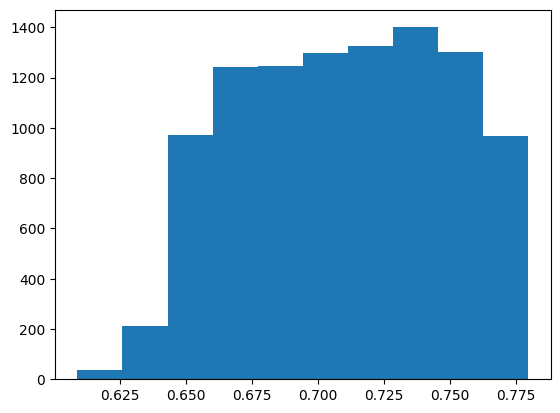

In [7]:
import matplotlib.pyplot as plt
plt.hist(garstec_df.sample(10000)['xini'])

In [6]:
garstec_df.to_hdf('../grids/Chiara-dnufit.hdf5', key = 'df')

In [43]:
test = garstec_df[(garstec_df['FeH']> -1.1)&(garstec_df['FeH'] < -0.9)&(garstec_df['age'] > 9000)].sample(10000)

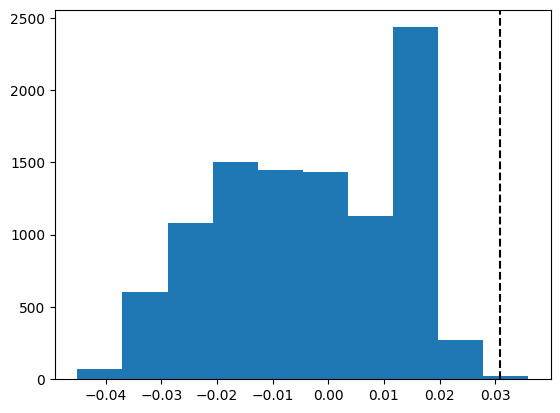

In [59]:
import matplotlib.pyplot as plt
plt.hist((test['dnuSer'] - test['dnuAsf'])/test['dnuAsf'])
plt.axvline(np.mean(ednu/dnu), linestyle = '--', color = 'black')


In [16]:
np.mean(100*(1 - test['numax']/test['numaxAsf'])), np.std(100*(1 - test['numax']/test['numaxAsf']))

(np.float64(-0.07055611791055405), np.float64(4.007942125603277e-08))

(array([  1.,   2.,   0.,   1.,   1.,   3.,   9.,   8.,  14.,  15.,  24.,
         29.,  43.,  72., 136., 353., 215.,  31.,   9.,   2.,   4.,   4.,
          5.,   5.,   0.,   2.,   0.,   1.,   2.,   0.,   1.,   1.,   0.,
          1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-0.48485689, -0.45369241, -0.42252793, -0.39136346, -0.36019898,
        -0.3290345 , -0.29787003, -0.26670555, -0.23554107, -0.2043766 ,
        -0.17321212, -0.14204764, -0.11088316, -0.07971869, -0.04855421,
        -0.01738973,  0.01377474,  0.04493922,  0.0761037 ,  0.10726817,
         0.13843265,  0.16

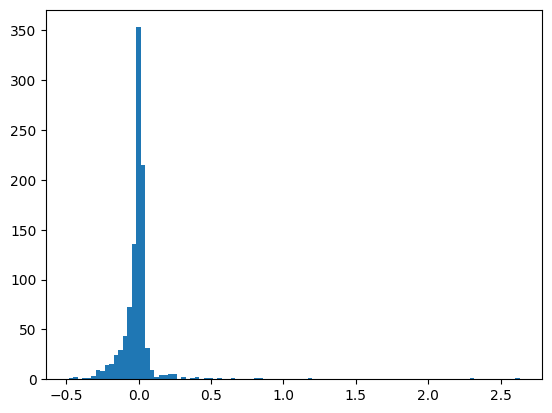

In [25]:
plt.hist(135*(test['dnuSer'] - test['dnuAsf']), bins = 100)

In [27]:
np.std(135*(test['dnuSer'] - test['dnuAsf']))

np.float64(0.1530192840428064)

In [46]:
Y25 = pd.read_csv('M4_seismicanalysis_Yingxiang_Feb25.csv')
Y25 = Y25[(Y25['Quality_flag'] == 'D')&(Y25['evol_stage'] == 'RGB')&(Y25['numax_pyMon']>12)&(Y25['Delta_nu']>0)]

IDs = Y25['star_id']

numax = Y25['numax_pyMon']
enumax_obs = Y25['numax_err_pyMon']
enumax_pred = 0.009*numax
enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = Y25['Delta_nu']
ednu_obs = 0.03*Y25['Delta_nu']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = Y25['Lum_bol']
eLPhot_obs = np.sqrt(Y25['Lum_bol_err_random']**2 + Y25['Lum_bol_err_systematic']**2)
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = Y25['Teff_final']
eTeff = Y25['Teff_err_final']

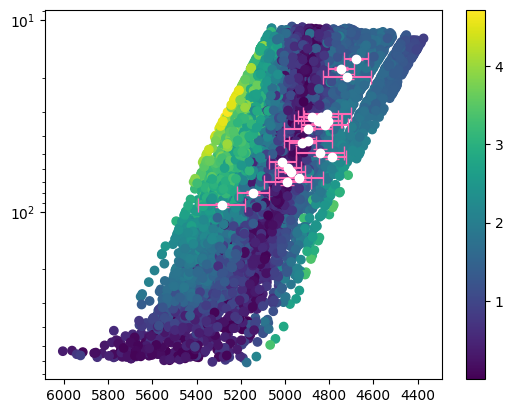

In [52]:
plt.scatter(test['Teff'], 3090*test['numaxAsf'], c = (np.abs(100*(test['dnuSer'] - test['dnuAsf'])/test['dnuSer'])), )
plt.errorbar(Teff, numax, xerr = eTeff, yerr = enumax, fmt = 'o', color = 'white', ecolor = 'hotpink', capsize = 5)
ax = plt.gca()
ax.invert_xaxis()
plt.semilogy()
plt.colorbar()
ax.invert_yaxis()